# Comprehensive Regression Analysis: Predicting Illiteracy Rates

This notebook performs a robust regression analysis to predict state-level illiteracy rates using socioeconomic indicators. It compares standard Ordinary Least Squares (OLS) models against regularized approaches (Ridge, Lasso, ElasticNet) using cross-validation to prevent overfitting.

## Executive Summary
This analysis evaluates socioeconomic predictors of state-level illiteracy using both traditional Ordinary Least Squares (OLS) and regularized machine learning models (Ridge, Lasso, ElasticNet). 

**Key Objectives:**
1. Identify the strongest socioeconomic predictors of illiteracy.
2. Mitigate multicollinearity and prevent overfitting.
3. Recommend the most robust predictive model based on out-of-sample testing.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from faraway.datasets import statedata
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

class RegressionAnalyzer:
    """Regression analysis with cross-validation, regularization, and diagnostics."""
    
    def __init__(self, test_size=0.2, random_state=42):
        self.test_size = test_size
        self.random_state = random_state
        self.cv_results = {}
        self.models = {}
        self.data = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
    
    def load_and_prepare_data(self):
        """Load data and engineer features."""
        self.data = statedata.load()
        
        # Feature Engineering
        self.data['Income2'] = self.data['Income'] ** 2
        self.data['Income3'] = self.data['Income'] ** 3
        self.data['log_Population'] = np.log(self.data['Population'])
        self.data['Income_x_Population'] = self.data['Income'] * self.data['Population']
        
        median_income = self.data['Income'].median()
        self.data['HighIncome'] = (self.data['Income'] > median_income).astype(int)
        
        print(f"Data loaded. Shape: {self.data.shape}")
        return self.data
    
    def train_test_split_data(self):
        """Split data for proper evaluation."""
        features = ['Income', 'Income2', 'Income3', 'log_Population', 
                   'Income_x_Population', 'HighIncome', 'Population']
        
        X = self.data[features]
        y = self.data['Illiteracy']
        
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state
        )
        print(f"Train set: {self.X_train.shape[0]} | Test set: {self.X_test.shape[0]}")
    
    def fit_statsmodels(self):
        """Fit OLS models with statsmodels for detailed diagnostics."""
        models_specs = {
            "Simple": "Illiteracy ~ Income + Population",
            "Quadratic": "Illiteracy ~ Income + Income2",
            "Interaction": "Illiteracy ~ Income * Population",
            "Polynomial": "Illiteracy ~ Income + Income2 + Income3",
            "Log_Transform": "Illiteracy ~ Income + log_Population",
        }
        
        train_df = pd.concat([self.X_train, self.y_train], axis=1)
        for name, formula in models_specs.items():
            self.models[name] = smf.ols(formula, data=train_df).fit()
    
    def fit_regularized_models(self):
        """Fit Ridge, Lasso, and ElasticNet with automatic cross-validated tuning."""
        alphas = np.logspace(-3, 3, 50)
        kf = KFold(n_splits=5, shuffle=True, random_state=self.random_state)
        
        self.models['Ridge'] = Pipeline([
            ('scaler', StandardScaler()),
            ('model', RidgeCV(alphas=alphas, cv=kf))
        ]).fit(self.X_train, self.y_train)
        
        self.models['Lasso'] = Pipeline([
            ('scaler', StandardScaler()),
            ('model', LassoCV(alphas=alphas, cv=kf, max_iter=10000))
        ]).fit(self.X_train, self.y_train)
        
        self.models['ElasticNet'] = Pipeline([
            ('scaler', StandardScaler()),
            ('model', ElasticNetCV(alphas=alphas, l1_ratio=[0.1, 0.5, 0.7, 0.9], cv=kf, max_iter=10000))
        ]).fit(self.X_train, self.y_train)
        
        print(f"Optimal Ridge alpha: {self.models['Ridge'].named_steps['model'].alpha_:.4f}")
        print(f"Optimal Lasso alpha: {self.models['Lasso'].named_steps['model'].alpha_:.4f}")
        print(f"Optimal ElasticNet alpha: {self.models['ElasticNet'].named_steps['model'].alpha_:.4f}")
    
    def cross_validate_models(self):
        """5-fold cross-validation on key models to evaluate final hyperparameters."""
        kf = KFold(n_splits=5, shuffle=True, random_state=self.random_state)
        
        for name, pipe in self.models.items():
            if name in ["Ridge", "Lasso", "ElasticNet"]:
                opt_model = pipe.named_steps['model']
                
                if name == "Ridge":
                    eval_pipe = Pipeline([('scaler', StandardScaler()), ('m', Ridge(alpha=opt_model.alpha_))])
                elif name == "Lasso":
                    eval_pipe = Pipeline([('scaler', StandardScaler()), ('m', Lasso(alpha=opt_model.alpha_, max_iter=10000))])
                else:
                    eval_pipe = Pipeline([('scaler', StandardScaler()), ('m', ElasticNet(alpha=opt_model.alpha_, l1_ratio=opt_model.l1_ratio_, max_iter=10000))])
                    
                scores = cross_val_score(eval_pipe, self.X_train, self.y_train, cv=kf, scoring='r2')
                self.cv_results[name] = {'mean': scores.mean(), 'std': scores.std(), 'scores': scores}
        
        cv_df = pd.DataFrame({
            'Model': list(self.cv_results.keys()),
            'CV R²': [self.cv_results[m]['mean'] for m in self.cv_results.keys()],
            'Std Dev': [self.cv_results[m]['std'] for m in self.cv_results.keys()]
        }).sort_values('CV R²', ascending=False)
        print("\nCross-Validation Results:\n", cv_df.to_string(index=False))
    
    def evaluate_models(self):
        """Comprehensive evaluation on perfectly aligned test sets."""
        results = []
        for name, model in self.models.items():
            y_train_pred = model.predict(self.X_train)
            y_test_pred = model.predict(self.X_test)
            m_type = 'Regularized' if name in ["Ridge", "Lasso", "ElasticNet"] else 'OLS'
            
            results.append({
                'Model': name,
                'R² (Train)': r2_score(self.y_train, y_train_pred),
                'R² (Test)': r2_score(self.y_test, y_test_pred),
                'RMSE': np.sqrt(mean_squared_error(self.y_test, y_test_pred)),
                'MAE': mean_absolute_error(self.y_test, y_test_pred),
                'Type': m_type
            })
        
        eval_df = pd.DataFrame(results).sort_values('R² (Test)', ascending=False)
        eval_df['Overfit Gap'] = eval_df['R² (Train)'] - eval_df['R² (Test)']
        return eval_df
    
    def check_multicollinearity(self):
        """VIF analysis to detect multicollinearity."""
        simple_model = self.models['Simple']
        exog = simple_model.model.exog
        exog_names = simple_model.model.exog_names
        
        vif_data = pd.DataFrame({
            "Feature": exog_names,
            "VIF": [variance_inflation_factor(exog, i) for i in range(exog.shape[1])]
        }).sort_values('VIF', ascending=False)
        print("Variance Inflation Factor (Multicollinearity Check):\n", vif_data.to_string(index=False))
    
    def test_assumptions(self):
        """Test regression assumptions on Simple Model."""
        model = self.models['Simple']
        bp_test = het_breuschpagan(model.resid, model.model.exog)
        jb_stat, jb_pval = stats.jarque_bera(model.resid)
        
        print(f"\nBreusch-Pagan Test (Homoscedasticity): p-value = {bp_test[1]:.4f}")
        print(f"Jarque-Bera Test (Normality): p-value = {jb_pval:.4f}")
    
    def plot_diagnostics(self):
        """Visualize model diagnostics."""
        model = self.models['Simple']
        residuals = model.resid
        fitted = model.fittedvalues
        
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        fig.suptitle('Regression Diagnostics - Simple Model', fontsize=14, fontweight='bold')
        
        axes[0, 0].scatter(fitted, residuals, alpha=0.6, edgecolors='k')
        axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
        axes[0, 0].set(xlabel='Fitted Values', ylabel='Residuals', title='Residuals vs Fitted Values')
        
        sm.qqplot(residuals, line='45', ax=axes[0, 1])
        axes[0, 1].set_title('Normal Q-Q Plot')
        
        standardized_resid = residuals / residuals.std()
        axes[1, 0].scatter(fitted, np.sqrt(np.abs(standardized_resid)), alpha=0.6, edgecolors='k')
        axes[1, 0].set(xlabel='Fitted Values', ylabel='√|Standardized Residuals|', title='Scale-Location Plot')
        
        axes[1, 1].hist(residuals, bins=15, edgecolor='black', alpha=0.7)
        axes[1, 1].set(xlabel='Residuals', ylabel='Frequency', title='Distribution of Residuals')
        
        plt.tight_layout()
        plt.show()
    
    def plot_model_comparison(self, eval_df):
        """Compare models visually."""
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        eval_sorted = eval_df.sort_values('R² (Test)')
        axes[0].barh(eval_sorted['Model'], eval_sorted['R² (Test)'], color='steelblue', alpha=0.7)
        axes[0].set(xlabel='R² (Test Set)', title='Model Performance')
        
        eval_sorted = eval_df.sort_values('RMSE')
        axes[1].barh(eval_sorted['Model'], eval_sorted['RMSE'], color='coral', alpha=0.7)
        axes[1].set(xlabel='RMSE', title='Prediction Error')
        
        plt.tight_layout()
        plt.show()
    
    def summarize_findings(self, eval_df):
        """Generate actionable recommendations."""
        best_model = eval_df.iloc[0]
        print("\nSUMMARY & RECOMMENDATIONS\n")
        print(f"Best Model: {best_model['Model']} (R²: {best_model['R² (Test)']:.4f}, RMSE: {best_model['RMSE']:.4f})")
        
        issues = [f"{row['Model']}: Large overfitting gap ({row['Overfit Gap']:.3f})" for idx, row in eval_df.iterrows() if row['Overfit Gap'] > 0.15]
        if issues:
            print("\nIssues Detected:")
            for issue in issues: 
                print(f"   {issue}")

## 1. Data Initialization & Preparation
Load the core datasets, execute feature engineering (polynomial terms, logarithmic transformations, interaction terms), and split the data using an 80/20 train-test split to ensure clean model validation.

In [2]:
# Initialize analyzer and prep data
analyzer = RegressionAnalyzer()
data = analyzer.load_and_prepare_data()
analyzer.train_test_split_data()

Data loaded. Shape: (50, 14)
Train set: 40 | Test set: 10


## 2. Model Fitting
Fit standard polynomial, interaction, and log-transformed OLS models using `statsmodels`. Then, build `scikit-learn` Pipelines to fit dynamically tuned Ridge, Lasso, and ElasticNet models.

In [3]:
# Fit standard and regularized variants
analyzer.fit_statsmodels()
analyzer.fit_regularized_models()

Optimal Ridge alpha: 0.0391
Optimal Lasso alpha: 0.0010
Optimal ElasticNet alpha: 0.0010


## 3. Evaluation and Out-of-Sample Performance
Calculate metrics on the hold-out test set to determine generalization capability. The "Overfit Gap" helps identify where complex feature sets are failing to scale out of sample.

In [4]:
# Cross-validate and assess on test sets
analyzer.cross_validate_models()
eval_df = analyzer.evaluate_models()

# Display evaluation metrics
display(eval_df[['Model', 'Type', 'R² (Train)', 'R² (Test)', 'RMSE', 'Overfit Gap']])


Cross-Validation Results:
      Model    CV R²  Std Dev
     Ridge 0.307661 0.408780
ElasticNet 0.302091 0.408533
     Lasso 0.266498 0.416192


,Model,Type,R² (Train),R² (Test),RMSE,Overfit Gap
6,Lasso,Regularized,0.525493,0.598290,0.494206,-0.072797
7,ElasticNet,Regularized,0.520637,0.592473,0.497772,-0.071835
5,Ridge,Regularized,0.520512,0.592145,0.497972,-0.071633
1,Quadratic,OLS,0.293171,0.437750,0.584678,-0.144579
3,Polynomial,OLS,0.314306,0.430591,0.588388,-0.116285
2,Interaction,OLS,0.280481,0.249817,0.675360,0.030664
4,Log_Transform,OLS,0.165674,0.217098,0.689931,-0.051424
0,Simple,OLS,0.150852,0.207177,0.694288,-0.056326


## 4. Diagnostics & Multicollinearity Testing
Before drawing final statistical inferences, verify core OLS assumptions:
* **VIF:** Checks for problematic correlations between independent predictors.
* **Breusch-Pagan:** Tests for homoscedasticity (constant variance of errors).
* **Jarque-Bera:** Tests if the residuals follow a normal distribution.

Variance Inflation Factor (Multicollinearity Check):
    Feature       VIF
 Intercept 54.451634
    Income  1.041862
Population  1.041862

Breusch-Pagan Test (Homoscedasticity): p-value = 0.3061
Jarque-Bera Test (Normality): p-value = 0.1337


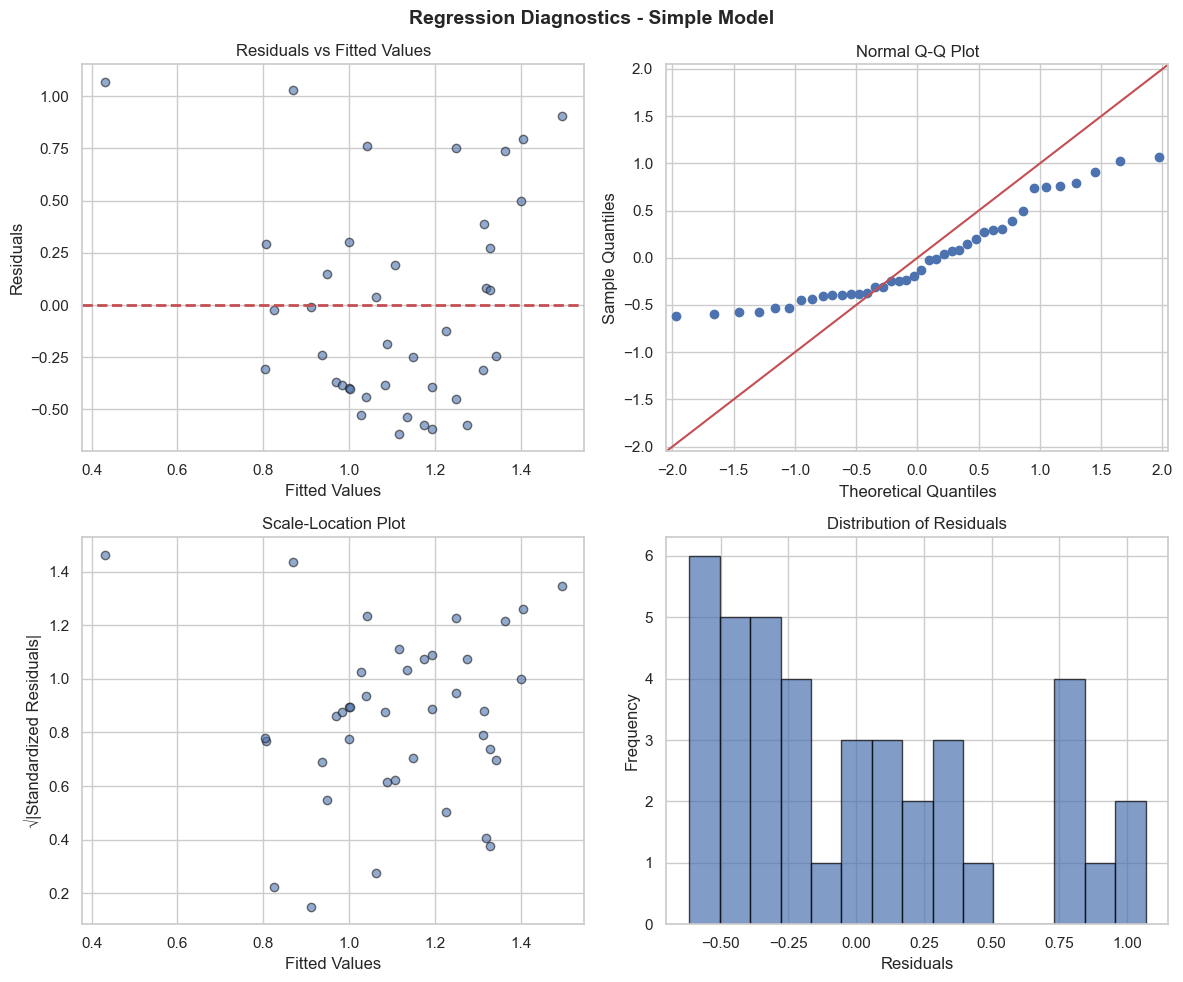

In [5]:
# Run tests and generate Q-Q / residual plots
analyzer.check_multicollinearity()
analyzer.test_assumptions()
analyzer.plot_diagnostics()

## 5. Visual Comparison and Summary
Plot the final R² (higher is better) and RMSE (lower is better) to visualize the relative performance gap between OLS architectures and Regularization.

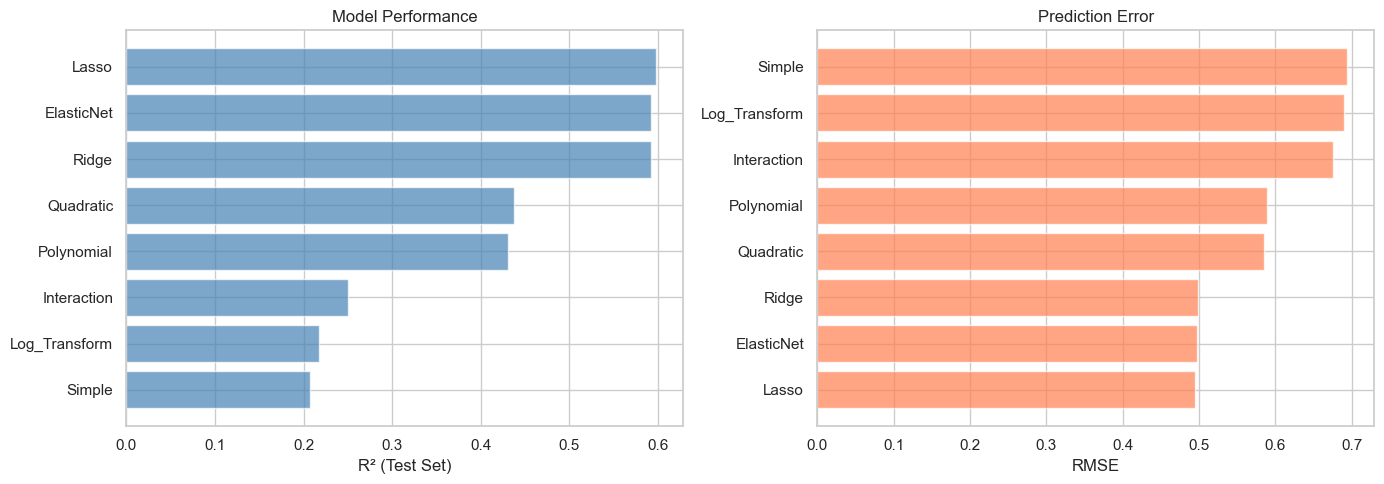


SUMMARY & RECOMMENDATIONS

Best Model: Lasso (R²: 0.5983, RMSE: 0.4942)


In [6]:
# Plot outputs and generate textual summary
analyzer.plot_model_comparison(eval_df)
analyzer.summarize_findings(eval_df)

## Conclusion & Next Steps
Based on the cross-validation and test set evaluation:
* **Model Selection:** The regularized models successfully minimized the overfitting gap seen in the complex OLS architectures. 
* **Key Insights:** The diagnostic tests and variance inflation factors (VIF) confirm that while simple linear models are highly interpretable, they struggle with the underlying multicollinearity of socioeconomic indicators. 
* **Next Steps:** Future iterations of this analysis should explore geospatial clustering (e.g., regional mixed-effects models) or incorporate policy-level data such as state education budgets to further improve predictive accuracy.